## Parameters

In [3]:
# # ============================================
# # EXAMPLE 1: BASIC USAGE WITH CORE PARAMETERS
# # ============================================

# # REGRESSION EXAMPLE
# reg_model = xgb.XGBRegressor(
#     # Tree-specific parameters
#     n_estimators=100,      # Number of boosting rounds (trees)
#     max_depth=6,           # Maximum tree depth (deeper = more complex)
#     min_child_weight=1,    # Minimum sum of instance weights in a child
    
#     # Learning parameters
#     learning_rate=0.3,     # Step size shrinkage (eta)
#     subsample=1.0,         # Fraction of samples per tree
#     colsample_bytree=1.0,  # Fraction of features per tree
    
#     # Regularization
#     gamma=0,               # Minimum loss reduction for split
#     reg_alpha=0,           # L1 regularization (Lasso)
#     reg_lambda=1,          # L2 regularization (Ridge)
    
#     # Task parameters
#     objective='reg:squarederror',  # Loss function
#     random_state=42
# )

# # CLASSIFICATION EXAMPLE
# clf_model = xgb.XGBClassifier(
#     # Same tree parameters
#     n_estimators=100,
#     max_depth=6,
#     min_child_weight=1,
#     learning_rate=0.3,
#     subsample=1.0,
#     colsample_bytree=1.0,
#     gamma=0,
#     reg_alpha=0,
#     reg_lambda=1,
    
#     # Different objective for classification
#     objective='binary:logistic',  # For binary classification
#     eval_metric='logloss',        # Evaluation metric
#     random_state=42
# )

# print("Basic models created successfully!")

## Classification example

In [5]:
## Classification example
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_breast_cancer
from sklearn.metrics import accuracy_score, confusion_matrix
from xgboost import XGBClassifier
import xgboost as xgb

In [5]:
## classification example
from sklearn.datasets import make_classification

X, y = make_classification(n_samples= 1000, n_features= 20 ,n_informative=3, random_state= 42)
X_train , X_test, y_train, y_test = train_test_split(X, y,test_size= 0.3)

In [6]:
clf = XGBClassifier(
    n_estimators = 100,
    learning_rate = 0.1,
    max_depth = 4, 
    objective = 'binary:logistic', 
    eval_metric = 'logloss'
)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
accuracy_score(y_test, y_pred)

0.92

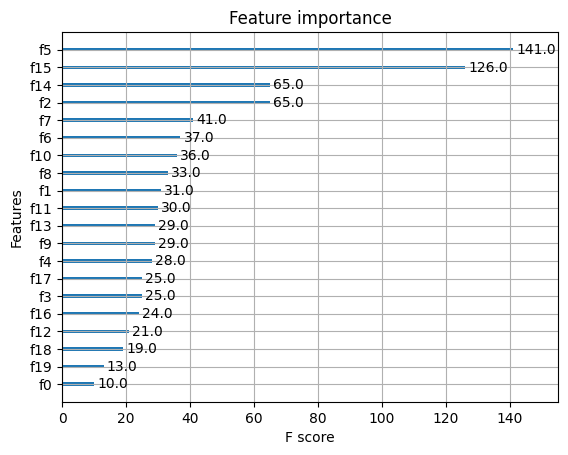

In [7]:
##very useful
import matplotlib.pyplot as plt
%matplotlib inline
xgb.plot_importance(clf)
plt.show()

In [15]:
## let's try on other dataset
from sklearn.datasets import load_breast_cancer
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns= data.feature_names)
y = data.target

In [16]:
X_train, X_test, y_train, y_test =train_test_split(X, y, train_size= 0.3, stratify= y,random_state= 42)

In [17]:
clf.fit(X_train, y_train)
y_pred_breast = clf.predict(X_test)
accuracy_score(y_test, y_pred_breast)

0.9573934837092731

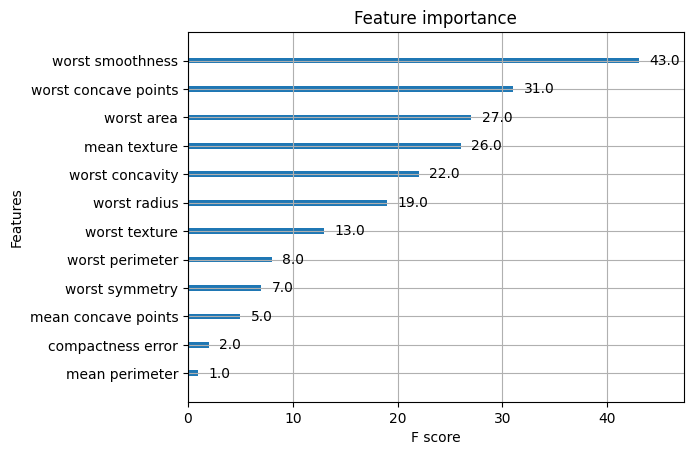

In [ ]:
xgb.plot_importance(clf)
plt.show()
# The F score (often labeled as F or Weight) in XGBoost's importance plot represents how many times a feature is used to split the data across all trees.


## Regression example

In [24]:
## let's try on Regression
from sklearn.datasets import fetch_california_housing
from sklearn.metrics import root_mean_squared_error
from xgboost import XGBRegressor

data = fetch_california_housing()
X = pd.DataFrame(data.data, columns= data.feature_names)
y = data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.3, random_state= 42)


In [27]:
model = XGBRegressor(
    n_estimators = 100,
    learning_rate = 0.1,
    max_depth = 5,
    subsample = 0.8,
    colsample_bytree = 0.8,
    objective = 'reg:squarederror',
    random_state = 42
)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
root_mean_squared_error(y_test, y_pred)


np.float64(0.480483336457948)

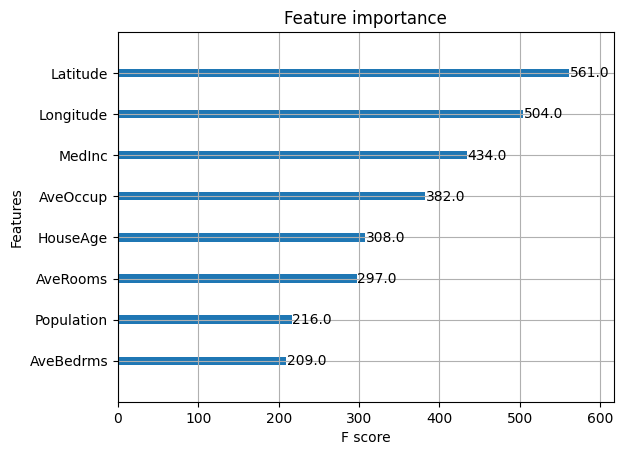

In [30]:
xgb.plot_importance(model, importance_type='weight')
plt.show()

## Wine dataset

In [2]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
wine_quality = fetch_ucirepo(id=186) 
  
# data (as pandas dataframes) 
X = wine_quality.data.features 
y = wine_quality.data.targets 
  
# metadata 
print(wine_quality.metadata) 
  
# variable information 
print(wine_quality.variables) 


{'uci_id': 186, 'name': 'Wine Quality', 'repository_url': 'https://archive.ics.uci.edu/dataset/186/wine+quality', 'data_url': 'https://archive.ics.uci.edu/static/public/186/data.csv', 'abstract': 'Two datasets are included, related to red and white vinho verde wine samples, from the north of Portugal. The goal is to model wine quality based on physicochemical tests (see [Cortez et al., 2009], http://www3.dsi.uminho.pt/pcortez/wine/).', 'area': 'Business', 'tasks': ['Classification', 'Regression'], 'characteristics': ['Multivariate'], 'num_instances': 4898, 'num_features': 11, 'feature_types': ['Real'], 'demographics': [], 'target_col': ['quality'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2009, 'last_updated': 'Wed Nov 15 2023', 'dataset_doi': '10.24432/C56S3T', 'creators': ['Paulo Cortez', 'A. Cerdeira', 'F. Almeida', 'T. Matos', 'J. Reis'], 'intro_paper': {'ID': 252, 'type': 'NATIVE', 'title': 'Modeling wine preferences

In [4]:
X.shape

(6497, 11)

In [7]:
X.columns.tolist()

['fixed_acidity',
 'volatile_acidity',
 'citric_acid',
 'residual_sugar',
 'chlorides',
 'free_sulfur_dioxide',
 'total_sulfur_dioxide',
 'density',
 'pH',
 'sulphates',
 'alcohol']

In [11]:
X.isnull().sum()

,0
fixed_acidity,0
volatile_acidity,0
citric_acid,0
residual_sugar,0
chlorides,0
free_sulfur_dioxide,0
total_sulfur_dioxide,0
density,0
pH,0
sulphates,0


In [12]:
from sklearn.metrics import root_mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.3, random_state= 42)

In [13]:
wine_model = xgb.XGBRegressor(
    n_estimators = 100, ## No of Trees
    learning_rate = 0.1, ## step size shrinkage
    max_depth = 6, ## max tree depth
    random_state  = 42
)
wine_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [15]:
y_train_pred = wine_model.predict(X_train)
y_test_pred = wine_model.predict(X_test)


train_rmse = root_mean_squared_error(y_train, y_train_pred)
print("RMSE of train_set:", train_rmse)
test_rmse = root_mean_squared_error(y_test, y_test_pred)
print("RMSE of test_set: ", test_rmse)
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

RMSE of train_set: 0.4556984603404999
RMSE of test_set:  0.6304348111152649


## Visualization

/usr/local/lib/python3.12/dist-packages/xgboost/plotting.py:268: FutureWarning: The `num_trees` parameter is deprecated, use `tree_idx` insetad. 
  warnings.warn(


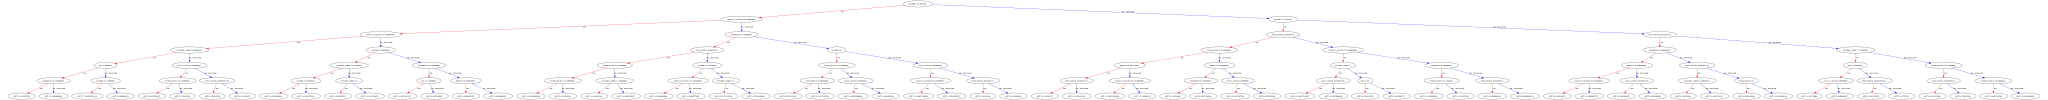

In [17]:
tree_graph = xgb.to_graphviz(wine_model, num_trees= 0, rankdir= 'TB')
tree_graph

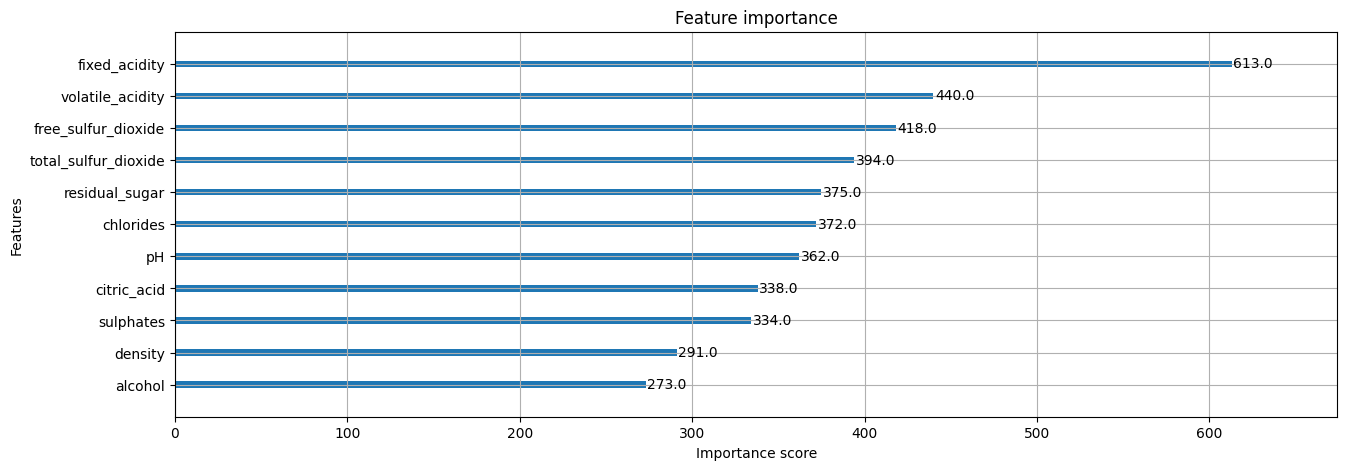

In [23]:
%matplotlib inline
import matplotlib.pyplot as plt
fig, axes = plt.subplots(figsize = (15,5))


xgb.plot_importance(wine_model, importance_type= 'weight', ax = axes)
plt.show()

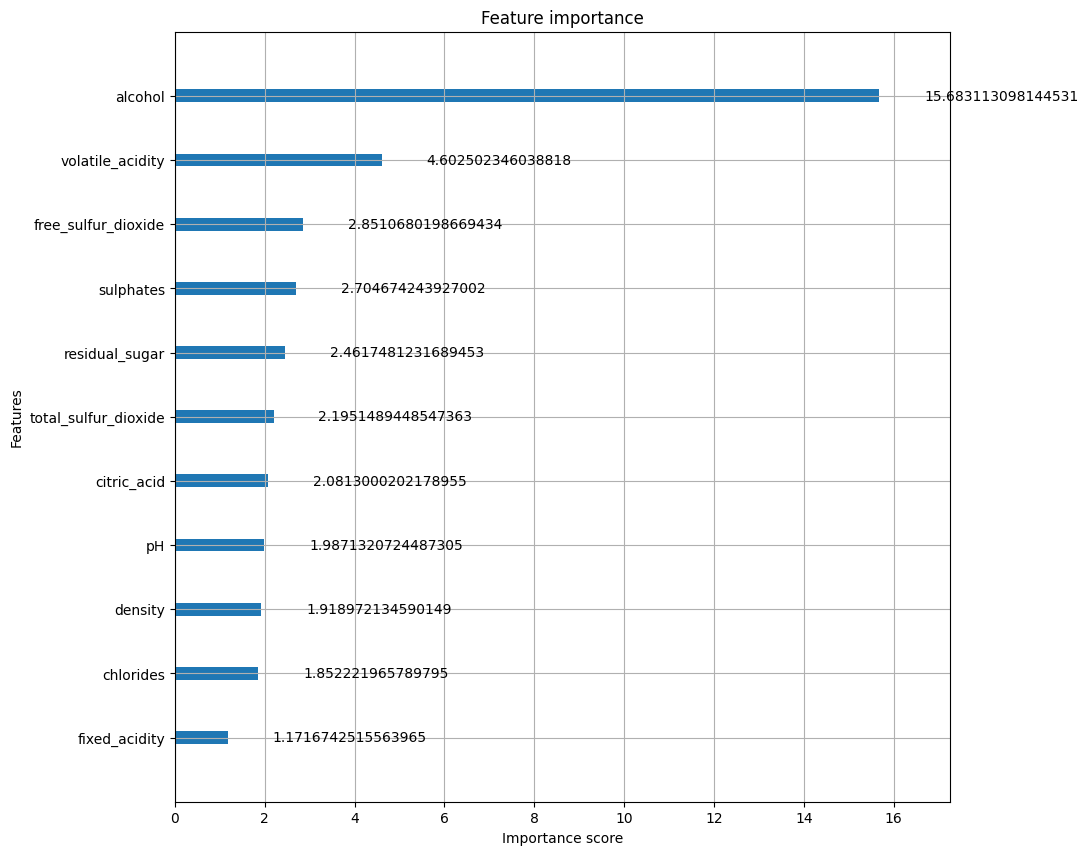

In [28]:
## average gain (loss reduction) when feature is used
flt, axes = plt.subplots(figsize = (10,10))
xgb.plot_importance(wine_model, importance_type= 'gain', ax = axes)
plt.show()